## 1. Project Summary & Problem Statement

### Project Overview
The goal of this project is to predict the severity of UK road accidents, specifically whether an accident will be Serious/Fatal or Slight. This can help road safety authorities identify the factors that increase accident severity (such as weather conditions, speed, and road type) and take preventive action based on that.


### Dataset Description
The data comes from STATS19 (official UK road accident data) for 2018, split into 3 files:
- Accidents_2018: 122,635 accidents, containing location, time, weather conditions, road type, and speed limit.
- Vehicles_2018: 226,409 vehicles, containing driver and vehicle information.
- Casualties_2018: 160,597 casualties (excluded from the model due to data leakage, explained below).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("merged_accidents_vehicles.csv")
df.head()

C:\Users\TEESLA\AppData\Local\Temp\ipykernel_16792\607611816.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_accidents_vehicles.csv")


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,veh_count,avg_driver_age,max_engine_cc,avg_vehicle_age,n_male_drivers
0,2018010080971,529150.0,182270.0,-0.139737,51.524587,1,3,2,2,01/01/2018,...,0,0,1,1,E01000854,2,40.0,1995.0,5.5,2
1,2018010080973,542020.0,184290.0,0.046471,51.539651,1,3,1,1,01/01/2018,...,0,0,1,1,E01003531,1,NaN,NaN,NaN,0
2,2018010080974,531720.0,182910.0,-0.102474,51.529746,1,3,2,1,01/01/2018,...,0,0,1,1,E01002723,2,30.5,1797.0,6.0,2
3,2018010080981,541450.0,183220.0,0.037828,51.530179,1,2,2,1,01/01/2018,...,0,0,1,1,E01003492,2,28.5,1200.0,1.0,2
4,2018010080982,543580.0,176500.0,0.065781,51.469258,1,2,2,2,01/01/2018,...,0,0,1,1,E01001682,2,49.0,1798.0,1.0,2


In [3]:
df.shape

(122635, 37)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122635 entries, 0 to 122634
Data columns (total 37 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Accident_Index                               122635 non-null  object 
 1   Location_Easting_OSGR                        122580 non-null  float64
 2   Location_Northing_OSGR                       122580 non-null  float64
 3   Longitude                                    122580 non-null  float64
 4   Latitude                                     122580 non-null  float64
 5   Police_Force                                 122635 non-null  int64  
 6   Accident_Severity                            122635 non-null  int64  
 7   Number_of_Vehicles                           122635 non-null  int64  
 8   Number_of_Casualties                         122635 non-null  int64  
 9   Date                                         122635 non-nul

In [5]:
df.isnull().sum().sort_values(ascending=False).head(15)

avg_vehicle_age              16457
max_engine_cc                14170
LSOA_of_Accident_Location     6445
avg_driver_age                5670
Location_Easting_OSGR           55
Location_Northing_OSGR          55
Latitude                        55
Longitude                       55
Time                            13
Accident_Index                   0
Police_Force                     0
Number_of_Vehicles               0
Accident_Severity                0
Local_Authority_(Highway)        0
1st_Road_Class                   0
dtype: int64

In [6]:
df.describe()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),...,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,veh_count,avg_driver_age,max_engine_cc,avg_vehicle_age,n_male_drivers
count,122580.000000,1.225800e+05,122580.000000,122580.000000,122635.000000,122635.000000,122635.000000,122635.000000,122635.000000,122635.000000,...,122635.000000,122635.000000,122635.000000,122635.000000,122635.000000,122635.000000,116965.000000,108465.000000,106178.000000,122635.000000
mean,451386.466993,2.827828e+05,-1.264938,52.432318,28.329947,2.783855,1.846202,1.309553,4.098463,327.148220,...,1.267118,0.075712,0.046789,1.327019,1.293905,1.846202,40.661076,2189.160752,8.184617,1.169006
std,95160.136962,1.529706e+05,1.395583,1.377821,24.869499,0.443486,0.721339,0.763476,1.926830,257.396769,...,0.596712,0.650032,0.529828,0.470133,0.472232,0.721339,14.015527,1920.592450,4.652245,0.798313
min,84654.000000,1.023500e+04,-7.266148,49.912362,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,48.000000,1.000000,0.000000
25%,387093.000000,1.758900e+05,-2.193964,51.469092,5.000000,3.000000,1.000000,1.000000,2.000000,85.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,30.000000,1399.000000,4.500000,1.000000
50%,457713.000000,2.234810e+05,-1.147169,51.893531,23.000000,3.000000,2.000000,1.000000,4.000000,305.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000,39.000000,1798.000000,8.000000,1.000000
75%,528980.000000,3.885220e+05,-0.140973,53.391034,45.000000,3.000000,2.000000,1.000000,6.000000,512.000000,...,2.000000,0.000000,0.000000,2.000000,2.000000,2.000000,49.500000,2143.000000,11.000000,2.000000
max,655275.000000,1.209512e+06,1.758123,60.763722,98.000000,3.000000,24.000000,59.000000,7.000000,941.000000,...,5.000000,7.000000,7.000000,3.000000,3.000000,24.000000,100.000000,99999.000000,83.000000,14.000000


## 2. Data Cleaning & Pre-processing

### Data Cleaning
- Accident_Index had mixed types (str and int) in the same column, so they were unified to str.
- The relationship between Accidents and Vehicles is one-to-many (each accident can have multiple vehicles), so the Vehicles data was aggregated (average driver age, max engine capacity, average vehicle age, number of male drivers) before merging with Accidents.
- Casualties was excluded entirely from the merge, because any information from it (such as Casualty_Severity) is nearly identical to the target and would cause data leakage.
- Rows missing geographic coordinates or time (0.05% of the data) were dropped, since the proportion is negligible.
- The LSOA_of_Accident_Location column was dropped due to high cardinality (thousands of distinct values) and because the same information is already captured in other columns (Latitude/Longitude).
- Numeric columns containing -1 (meaning "unknown") were converted to NaN before any calculation, so -1 wouldn't distort the averages.
- Checked for duplicate records in the final dataset; none were found.


In [7]:
df = df.drop(columns=['LSOA_of_Accident_Location','Number_of_Vehicles'])

df = df.dropna(subset=['Longitude', 'Latitude', 'Location_Easting_OSGR','Location_Northing_OSGR', 'Time'])

print(df.shape)
print(df.isna().sum().sort_values(ascending=False).head(10))

(122567, 35)
avg_vehicle_age           16444
max_engine_cc             14156
avg_driver_age             5666
Location_Northing_OSGR        0
Location_Easting_OSGR         0
Accident_Index                0
Longitude                     0
Number_of_Casualties          0
Latitude                      0
Police_Force                  0
dtype: int64


In [8]:
print(df.duplicated().sum())
print(df.duplicated(subset=['Accident_Index']).sum())

0
0


In [9]:
df['driver_age_missing'] = df['avg_driver_age'].isna().astype(int)
df['engine_cc_missing'] = df['max_engine_cc'].isna().astype(int)
df['vehicle_age_missing'] = df['avg_vehicle_age'].isna().astype(int)

for col in ['driver_age_missing', 'engine_cc_missing', 'vehicle_age_missing']:
    print(df.groupby(col)['Accident_Severity'].value_counts(normalize=True))

driver_age_missing  Accident_Severity
0                   3                    0.795930
                    2                    0.190015
                    1                    0.014055
1                   3                    0.830392
                    2                    0.165019
                    1                    0.004589
Name: proportion, dtype: float64
engine_cc_missing  Accident_Severity
0                  3                    0.801976
                   2                    0.184253
                   1                    0.013772
1                  3                    0.763422
                   2                    0.224145
                   1                    0.012433
Name: proportion, dtype: float64
vehicle_age_missing  Accident_Severity
0                    3                    0.803012
                     2                    0.183268
                     1                    0.013720
1                    3                    0.762102
                     2

In [10]:
df.loc[df['max_engine_cc'] > 10000, 'max_engine_cc'] = np.nan
df.loc[df['avg_driver_age'] < 15, 'avg_driver_age'] = np.nan

print(df['max_engine_cc'].isna().sum())
print(df['avg_driver_age'].isna().sum())

16448
6114


In [11]:
from sklearn.model_selection import train_test_split

df['is_KSI'] = df['Accident_Severity'].apply(lambda x: 1 if x in [1, 2] else 0)

y = df['is_KSI']
X = df.drop(columns=['is_KSI', 'Accident_Severity', 'Accident_Index'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(98053, 36) (24514, 36)
is_KSI
0    0.797528
1    0.202472
Name: proportion, dtype: float64


In [12]:
for col, new_col in [('avg_driver_age', 'driver_age_missing'),('max_engine_cc', 'engine_cc_missing'),('avg_vehicle_age', 'vehicle_age_missing')]:
    X_train[new_col] = X_train[col].isna().astype(int)
    X_test[new_col] = X_test[col].isna().astype(int)

In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor

cols_to_impute = ['avg_driver_age', 'max_engine_cc', 'avg_vehicle_age', 'veh_count', 'n_male_drivers']

imputer = IterativeImputer(
    estimator=DecisionTreeRegressor(max_depth=8, random_state=1),
    max_iter=10,
    random_state=1)

X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.transform(X_test[cols_to_impute])

print(X_train[cols_to_impute].isna().sum())
print(X_test[cols_to_impute].isna().sum())

avg_driver_age     0
max_engine_cc      0
avg_vehicle_age    0
veh_count          0
n_male_drivers     0
dtype: int64
avg_driver_age     0
max_engine_cc      0
avg_vehicle_age    0
veh_count          0
n_male_drivers     0
dtype: int64


c:\Users\TEESLA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### Feature Engineering
- Hour, Month, Is_Weekend: extracted from the original Date/Time columns to capture the effect of time of day and season on accidents.
- 3 missing-value flag columns (driver_age_missing, engine_cc_missing, vehicle_age_missing): added because the absence of this data itself turned out to be correlated with a higher proportion of severe accidents (not random), so this information was kept available for the model instead of being lost after imputation.


In [14]:
for data in [X_train, X_test]:
    data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
    data['Hour'] = pd.to_datetime(data['Time'], format='%H:%M').dt.hour
    data['Month'] = data['Date'].dt.month
    data['Is_Weekend'] = data['Day_of_Week'].isin([1, 7]).astype(int)

X_train = X_train.drop(columns=['Date', 'Time'])
X_test = X_test.drop(columns=['Date', 'Time'])

print(X_train[['Hour', 'Month', 'Is_Weekend']].isna().sum())

Hour          0
Month         0
Is_Weekend    0
dtype: int64


In [15]:
df.columns

Index(['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR',
       'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity',
       'Number_of_Casualties', 'Date', 'Day_of_Week', 'Time',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       'Junction_Detail', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'veh_count', 'avg_driver_age', 'max_engine_cc', 'avg_vehicle_age',
       'n_male_drivers', 'driver_age_missing', 'engine_cc_missing',
       'vehicle_age_missing', 'is_KSI'],
      dtype='object')

### Data Transformation
- Missing values in the heavy-missing columns (avg_driver_age, max_engine_cc, avg_vehicle_age) were filled using IterativeImputer (with a Decision Tree), instead of a simple mean/median, since the missingness wasn't random.
- The Local_Authority_(Highway) column (text, with hundreds of values) was converted to a number using Target Encoding.
- All numeric columns were Standard Scaled, but in two separate versions: a scaled version for distance-based models (e.g., Logistic Regression, KNN), and an unscaled version for tree-based models (e.g., Random Forest, XGBoost) which don't need it.
- Every step (Imputer, Target Encoder, Scaler) was fit on the training data only and applied (transform) to the test data, to ensure no data leakage.

In [16]:
from category_encoders import TargetEncoder

te = TargetEncoder(cols=['Local_Authority_(Highway)'], smoothing=5)

X_train['Local_Authority_(Highway)'] = te.fit_transform(X_train['Local_Authority_(Highway)'], y_train)
X_test['Local_Authority_(Highway)'] = te.transform(X_test['Local_Authority_(Highway)'])

print(X_train['Local_Authority_(Highway)'].head())
print(X_train.dtypes.value_counts())

111892    0.233969
25042     0.168508
99488     0.214559
25279     0.111898
104437    0.236437
Name: Local_Authority_(Highway), dtype: float64
int64      25
float64    10
int32       2
Name: count, dtype: int64


In [17]:
from sklearn.preprocessing import StandardScaler

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

feature_names = X_train_encoded.columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train_encoded.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test_encoded.index)

X_train_raw = X_train_encoded
X_test_raw = X_test_encoded

print(X_train_scaled.describe().loc[['mean', 'std']].T.head())
print(X_train_raw.describe().loc[['mean', 'std']].T.head())

                                mean       std
Location_Easting_OSGR   4.347910e-17  1.000005
Location_Northing_OSGR -3.681231e-17  1.000005
Longitude               6.130553e-17  1.000005
Latitude                3.655143e-16  1.000005
Police_Force           -5.652283e-18  1.000005
                                 mean            std
Location_Easting_OSGR   451277.691575   95267.983144
Location_Northing_OSGR  282656.370300  152917.033454
Longitude                   -1.266599       1.397218
Latitude                    52.431173       1.377326
Police_Force                28.341581      24.883240


## 3. Exploratory Data Analysis (EDA)

Here we explore the cleaned accident-level dataset and look at how the main features are associated with the final target `is_KSI`.

The goal is to understand:
- the target distribution and class imbalance
- the distribution of important numerical features
- accident patterns by time, road environment, weather and lighting
- geographic patterns
- relationships between numerical features and `is_KSI`

> **Note:** These plots show associations useful for prediction; they do not prove causation.

Dataset shape: (122567, 39)

KSI distribution:
is_KSI
0    97750
1    24817
Name: count, dtype: int64

KSI percentage:
is_KSI
0    79.75
1    20.25
Name: proportion, dtype: float64


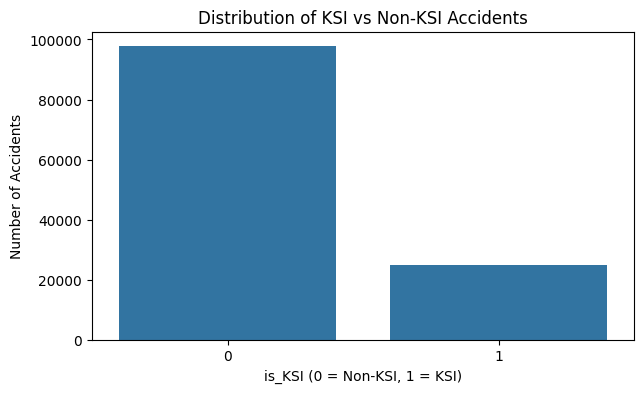

In [18]:
print("Dataset shape:", df.shape)
print("\nKSI distribution:")
print(df['is_KSI'].value_counts())

print("\nKSI percentage:")
print((df['is_KSI'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='is_KSI')
plt.title('Distribution of KSI vs Non-KSI Accidents')
plt.xlabel('is_KSI (0 = Non-KSI, 1 = KSI)')
plt.ylabel('Number of Accidents')
plt.show()

C:\Users\TEESLA\AppData\Local\Temp\ipykernel_16792\4276377405.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_check = pd.read_csv('merged_accidents_vehicles.csv')


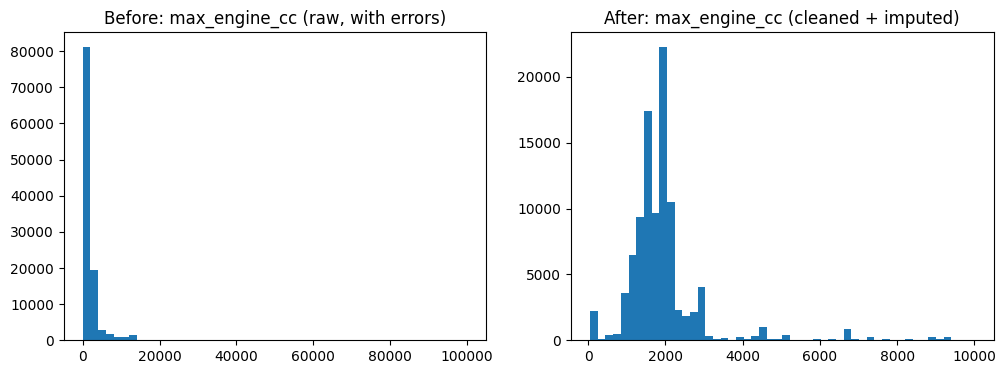

In [19]:
raw_check = pd.read_csv('merged_accidents_vehicles.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_check['max_engine_cc'].dropna(), bins=50)
axes[0].set_title('Before: max_engine_cc (raw, with errors)')

axes[1].hist(X_train_raw['max_engine_cc'], bins=50)
axes[1].set_title('After: max_engine_cc (cleaned + imputed)')
plt.show()

The raw `max_engine_cc` column had extreme outlier values (up to ~100,000), which are data entry errors rather than real engine sizes. After converting values above 10,000 to missing and imputing them, the distribution became realistic, with most values falling between 1,500-2,000 CC as expected for common vehicles.

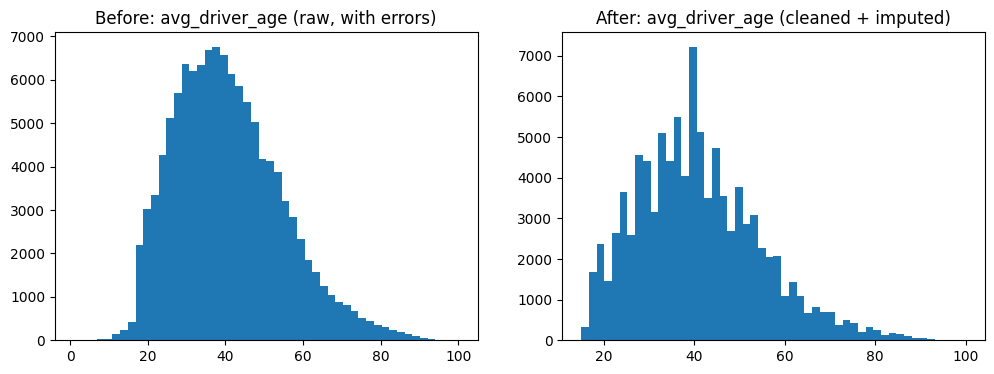

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_check['avg_driver_age'].dropna(), bins=50)
axes[0].set_title('Before: avg_driver_age (raw, with errors)')

axes[1].hist(X_train_raw['avg_driver_age'], bins=50)
axes[1].set_title('After: avg_driver_age (cleaned + imputed)')

plt.show()

The raw `avg_driver_age` column had a small number of invalid values (under 15 years old, 448 rows). After converting them to missing and imputing, the distribution stayed largely the same shape (peaking around 30-40 years), confirming the small effect size of this correction.

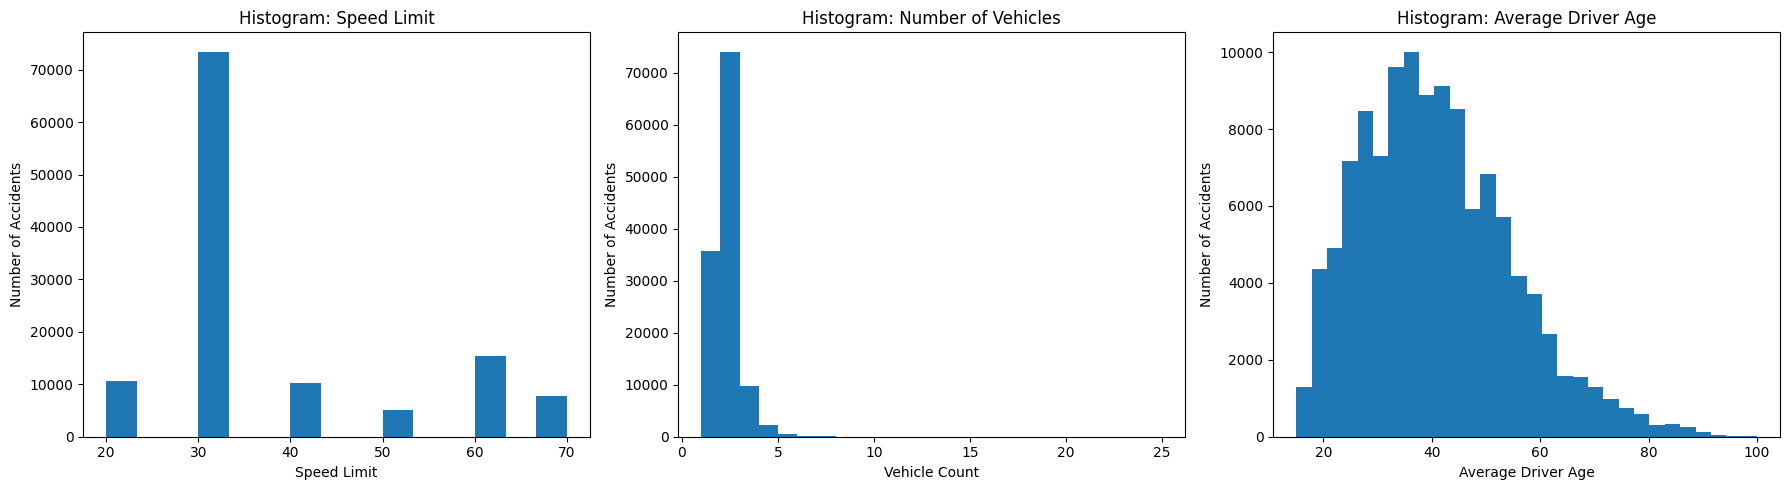

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Speed_limit'].dropna(), bins=15)
axes[0].set_title('Histogram: Speed Limit')
axes[0].set_xlabel('Speed Limit')
axes[0].set_ylabel('Number of Accidents')

axes[1].hist(df['veh_count'].dropna(), bins=range(1, int(df['veh_count'].max()) + 2))
axes[1].set_title('Histogram: Number of Vehicles')
axes[1].set_xlabel('Vehicle Count')
axes[1].set_ylabel('Number of Accidents')

axes[2].hist(df['avg_driver_age'].dropna(), bins=30)
axes[2].set_title('Histogram: Average Driver Age')
axes[2].set_xlabel('Average Driver Age')
axes[2].set_ylabel('Number of Accidents')

plt.tight_layout()
plt.show()

Speed limits are concentrated at 30 mph, reflecting the higher density of urban driving rather than a direct severity signal. Most accidents involve exactly 2 vehicles, consistent with typical two-car collisions. Average driver age follows a roughly normal distribution peaking around 35-40 years.

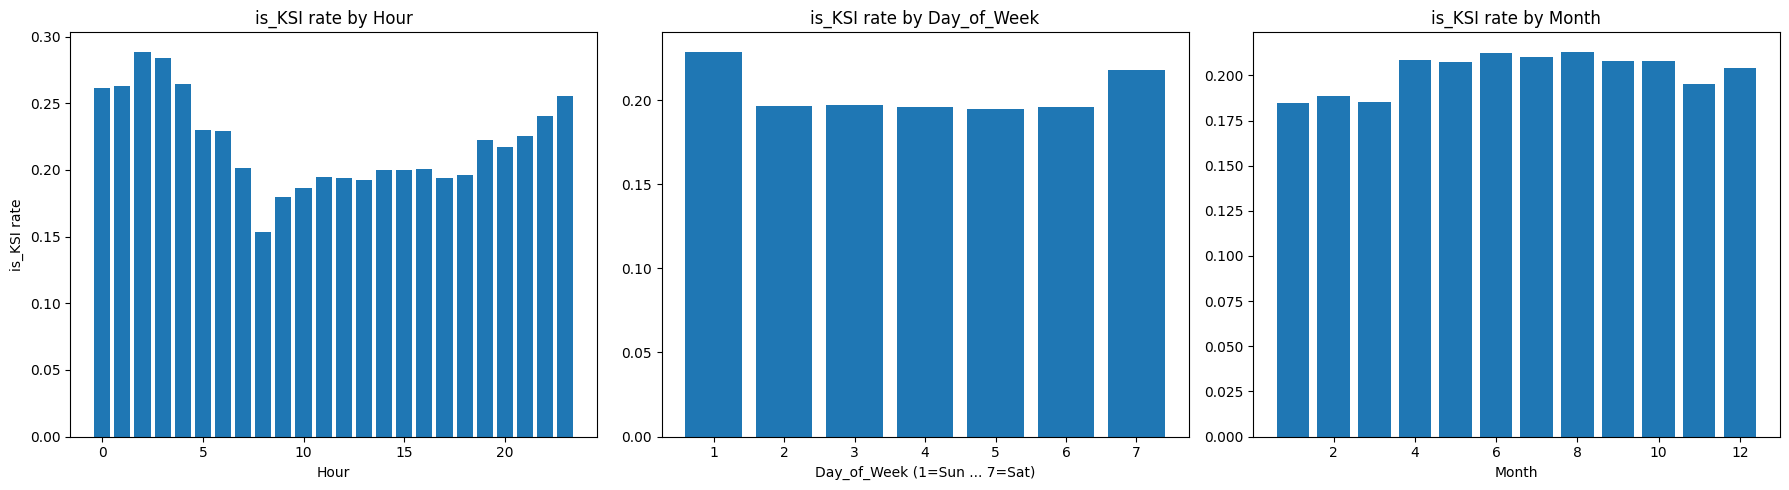

          mean  count
Hour                 
0     0.261580   1835
1     0.263241   1265
2     0.288699   1053
3     0.284173    834
4     0.264411    798
5     0.229549   1198
6     0.228814   2478
7     0.201561   5636
8     0.153684   8537
9     0.179946   5874
10    0.186224   5488
11    0.194958   6109
12    0.194066   7111
13    0.192432   7135
14    0.199709   7551
15    0.199642   9497
16    0.200889   9901
17    0.193591  10610
18    0.195924   8881
19    0.222171   6477
20    0.217252   4695
21    0.225367   3674
22    0.240502   3264
23    0.255064   2666


In [22]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
df['Month'] = df['Date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hour_ksi = df.groupby('Hour')['is_KSI'].agg(['mean', 'count'])
axes[0].bar(hour_ksi.index, hour_ksi['mean'])
axes[0].set_title('is_KSI rate by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('is_KSI rate')

day_ksi = df.groupby('Day_of_Week')['is_KSI'].agg(['mean', 'count'])
axes[1].bar(day_ksi.index, day_ksi['mean'])
axes[1].set_title('is_KSI rate by Day_of_Week')
axes[1].set_xlabel('Day_of_Week (1=Sun ... 7=Sat)')

month_ksi = df.groupby('Month')['is_KSI'].agg(['mean', 'count'])
axes[2].bar(month_ksi.index, month_ksi['mean'])
axes[2].set_title('is_KSI rate by Month')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.show()

print(hour_ksi)

The KSI rate (not the raw count) is highest during late-night hours (12-4 AM) and lowest during the morning rush (7-8 AM), suggesting night accidents are less frequent but more severe. Sundays and Saturdays show a higher KSI rate than weekdays, consistent with a "weekend effect" (higher speeds, more leisure driving). Monthly variation is mild, with slightly higher rates in summer months.

          mean  count     rate_%
Hour                            
2     0.288699   1053  28.869896
3     0.284173    834  28.417266
4     0.264411    798  26.441103
1     0.263241   1265  26.324111
0     0.261580   1835  26.158038
23    0.255064   2666  25.506377
22    0.240502   3264  24.050245
5     0.229549   1198  22.954925
6     0.228814   2478  22.881356
21    0.225367   3674  22.536745


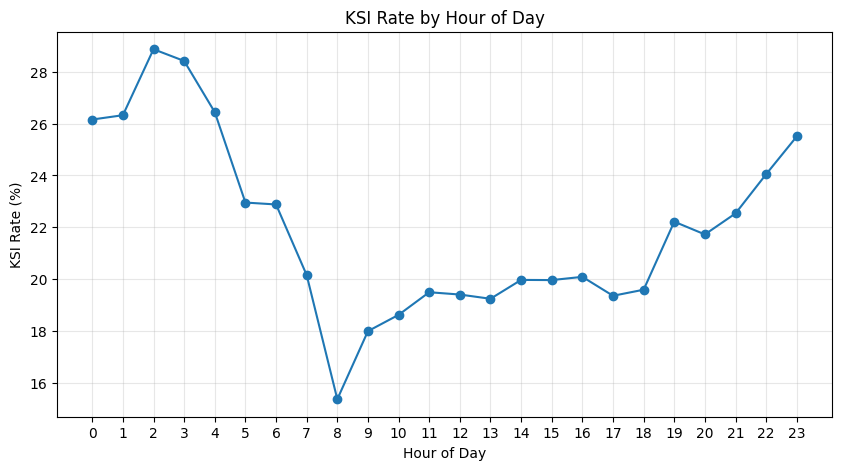

In [23]:
hour_ksi = df.groupby('Hour')['is_KSI'].agg(['mean', 'count'])
hour_ksi['rate_%'] = hour_ksi['mean'] * 100

print(hour_ksi.sort_values('rate_%', ascending=False).head(10))

plt.figure(figsize=(10, 5))
plt.plot(hour_ksi.index, hour_ksi['rate_%'], marker='o')
plt.title('KSI Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('KSI Rate (%)')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

This line chart confirms the same hourly pattern shown earlier in bar form, making the day/night cycle in KSI rate easier to see: it dips to its lowest point at 8 AM and peaks around 2 AM, following a smooth daily wave rather than random noise.

--- Road_Type ---
               mean  count  KSI_rate_%
Road_Type                             
6          0.216168  88274   21.616784
3          0.187343  19467   18.734268
2          0.173551   3365   17.355126
7          0.146179   1505   14.617940
1          0.136610   7569   13.660986
9          0.104734   2387   10.473398



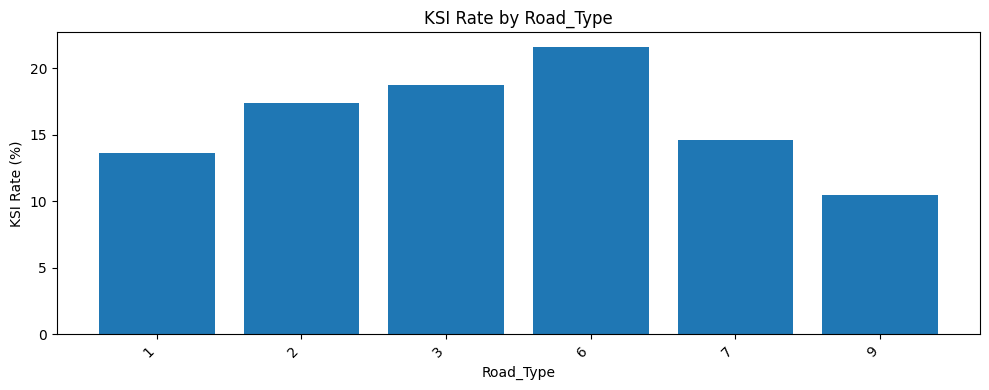

--- Urban_or_Rural_Area ---
                         mean  count  KSI_rate_%
Urban_or_Rural_Area                             
 2                   0.248650  39992   24.864973
 1                   0.180117  82574   18.011723
-1                   0.000000      1    0.000000



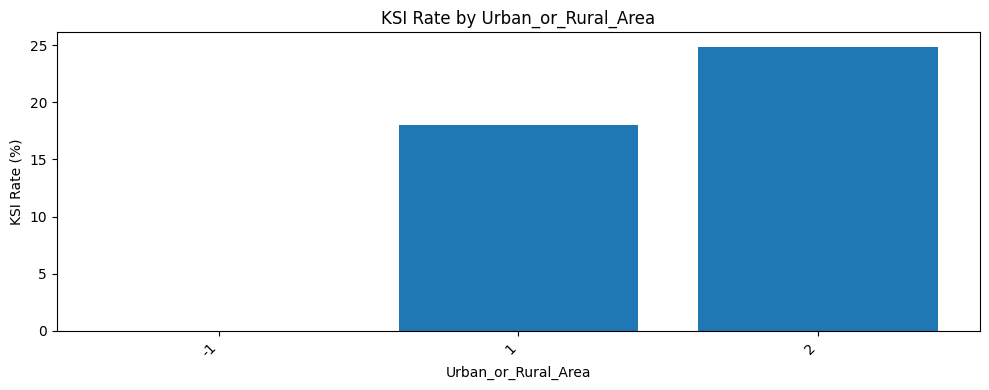

--- Light_Conditions ---
                      mean  count  KSI_rate_%
Light_Conditions                             
6                 0.309944   6114   30.994439
5                 0.245327    856   24.532710
4                 0.212174  24725   21.217391
1                 0.192997  88395   19.299734
7                 0.163908   2477   16.390795



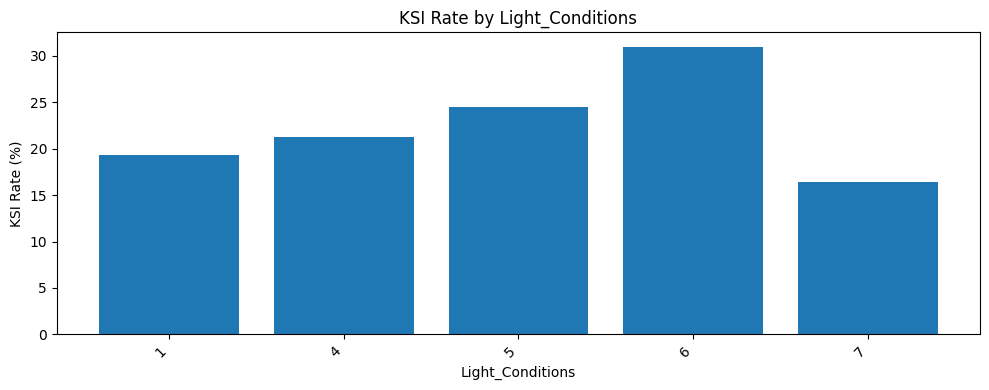

--- Weather_Conditions ---
                        mean  count  KSI_rate_%
Weather_Conditions                             
 7                  0.261161    448   26.116071
 5                  0.226312   1277   22.631167
 4                  0.225949   1133   22.594881
 1                  0.207454  99164   20.745432
 2                  0.192428  12784   19.242804
 6                  0.164179    402   16.417910
 3                  0.158140   1075   15.813953
 8                  0.155650   2602   15.564950
 9                  0.131277   3664   13.127729
-1                  0.055556     18    5.555556



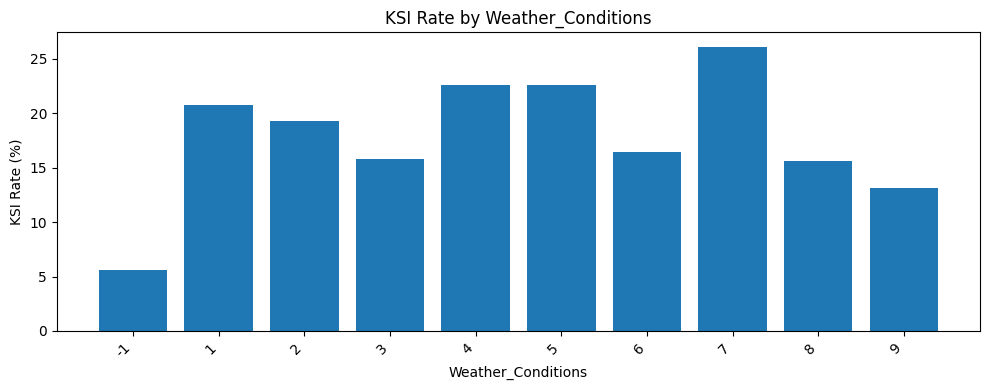

--- Road_Surface_Conditions ---
                             mean  count  KSI_rate_%
Road_Surface_Conditions                             
 5                       0.214815    135   21.481481
 2                       0.209065  28197   20.906479
 1                       0.203021  90498   20.302106
 4                       0.170078   1417   17.007763
 3                       0.151046   1099   15.104641
-1                       0.092547   1221    9.254709



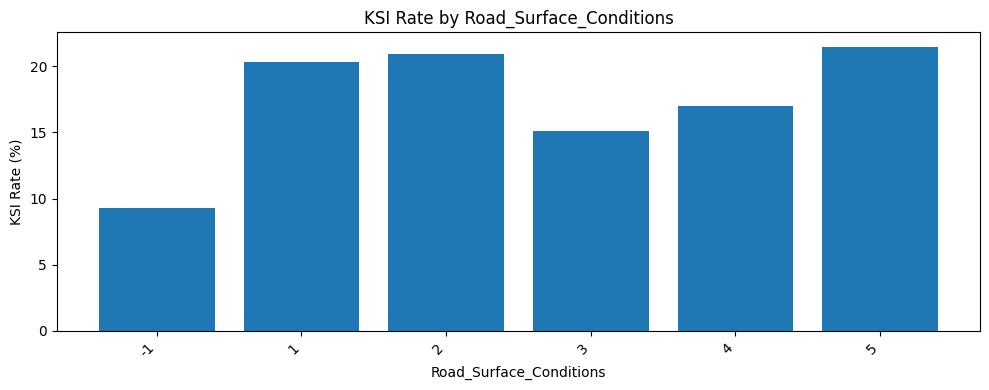

In [24]:
cat_cols_to_check = [
    'Road_Type',
    'Urban_or_Rural_Area',
    'Light_Conditions',
    'Weather_Conditions',
    'Road_Surface_Conditions'
]

for col in cat_cols_to_check:
    if col in df.columns:
        summary = df.groupby(col)['is_KSI'].agg(['mean', 'count'])
        summary['KSI_rate_%'] = summary['mean'] * 100
        print(f'--- {col} ---')
        print(summary.sort_values('KSI_rate_%', ascending=False))
        print()

        plt.figure(figsize=(10, 4))
        plt.bar(summary.index.astype(str), summary['KSI_rate_%'])
        plt.title(f'KSI Rate by {col}')
        plt.xlabel(col)
        plt.ylabel('KSI Rate (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

Across the categorical conditions (road type, area, light, weather, and surface), the highest KSI rates consistently appear in conditions that reduce driver visibility or control: darkness, fog, flooded roads, and single carriageways with higher speeds. Categories with very small sample sizes (e.g. -1/unknown) show extreme rates but are unreliable due to low counts.

                 mean  count  KSI_rate_%
Speed_limit                             
20           0.167308  10651   16.730823
30           0.184728  73454   18.472786
40           0.222070  10222   22.207005
50           0.228758   5049   22.875817
60           0.291932  15370   29.193234
70           0.198696   7821   19.869582


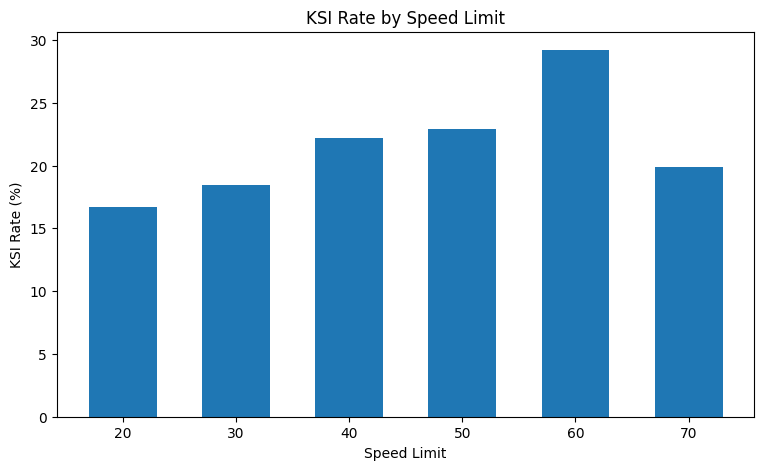

In [25]:
speed_ksi = df.groupby('Speed_limit')['is_KSI'].agg(['mean', 'count'])
speed_ksi['KSI_rate_%'] = speed_ksi['mean'] * 100

print(speed_ksi)

plt.figure(figsize=(9, 5))
plt.bar(speed_ksi.index.astype(str), speed_ksi['KSI_rate_%'], width=0.6)
plt.title('KSI Rate by Speed Limit')
plt.xlabel('Speed Limit')
plt.ylabel('KSI Rate (%)')
plt.show()

The relationship between speed limit and KSI rate is non-linear: the rate rises steadily from 20 to 60 mph, then drops at 70 mph. This is likely because 70 mph roads (motorways) are engineered with stricter safety standards despite the higher speed, which explains why the earlier Pearson correlation for Speed_limit was weak.

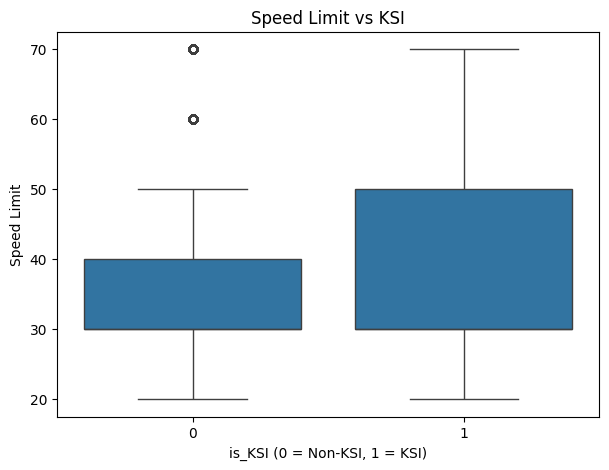

In [26]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='is_KSI', y='Speed_limit')
plt.title('Speed Limit vs KSI')
plt.xlabel('is_KSI (0 = Non-KSI, 1 = KSI)')
plt.ylabel('Speed Limit')
plt.show()

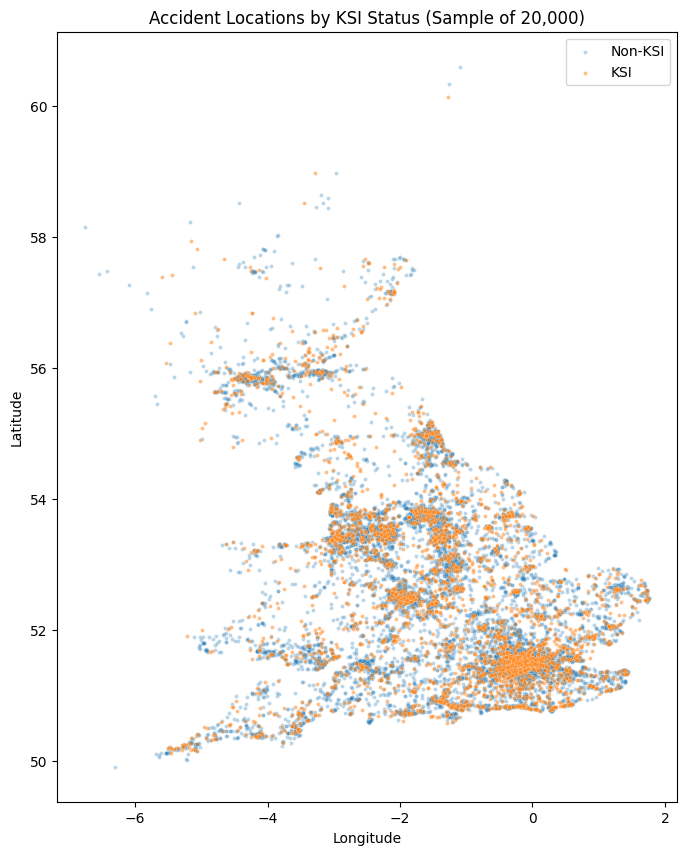

In [27]:
sample = df.sample(min(20000, len(df)), random_state=42)

plt.figure(figsize=(8, 10))

sns.scatterplot(
    data=sample[sample['is_KSI'] == 0],
    x='Longitude',
    y='Latitude',
    s=8,
    alpha=0.3,
    label='Non-KSI',
    legend=True
)

sns.scatterplot(
    data=sample[sample['is_KSI'] == 1],
    x='Longitude',
    y='Latitude',
    s=8,
    alpha=0.5,
    label='KSI',
    legend=True
)

plt.title('Accident Locations by KSI Status (Sample of 20,000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

The geographic scatter shows accident density concentrated in major urban areas (e.g. London), but KSI and Non-KSI points are visually intermixed with no clear location-based separation. This suggests raw coordinates add little predictive signal, and that the simpler Urban_or_Rural_Area column already captures the relevant pattern.

is_KSI                  1.000000
Urban_or_Rural_Area     0.081140
Speed_limit             0.070947
Number_of_Casualties    0.065098
avg_driver_age          0.046274
n_male_drivers          0.035577
avg_vehicle_age         0.029167
Hour                    0.005828
max_engine_cc          -0.018947
veh_count              -0.069291
Name: is_KSI, dtype: float64


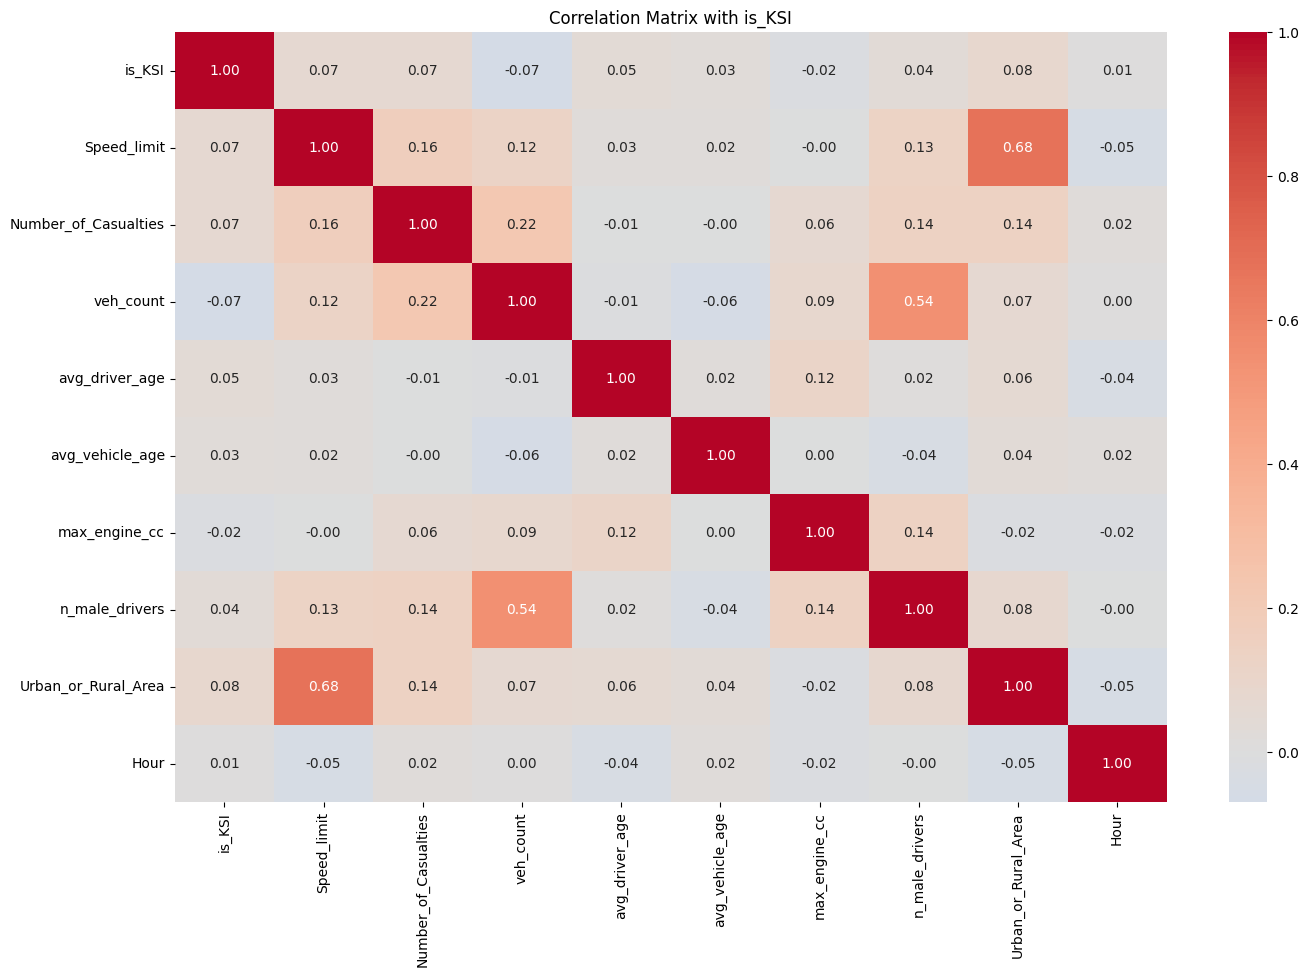

In [28]:
corr_df = X_train_raw.copy()
corr_df['is_KSI'] = y_train.values

corr_cols = ['is_KSI', 'Speed_limit', 'Number_of_Casualties', 'veh_count',
             'avg_driver_age', 'avg_vehicle_age', 'max_engine_cc', 'n_male_drivers',
             'Urban_or_Rural_Area', 'Hour']

corr = corr_df[corr_cols].corr()
print(corr['is_KSI'].sort_values(ascending=False))

plt.figure(figsize=(16, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix with is_KSI')
plt.show()

Correlations between the continuous numerical features and `is_KSI` are all weak (the highest being Urban_or_Rural_Area and Speed_limit/Number_of_Casualties at 0.07-0.08), confirming that severity depends mostly on non-linear and categorical patterns (time of day, road type, lighting) rather than simple linear relationships with these variables. The strongest inter-feature correlations are Speed_limit with Urban_or_Rural_Area (0.68) and veh_count with n_male_drivers (0.54).

## 4. Machine Learning Model & Evaluation

This is a binary classification problem: predicting `is_KSI` (1 = Serious/Fatal, 0 = Slight).
We compare several models (Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM) using cross-validation, then pick the best one and tune its decision threshold.

In [29]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, average_precision_score,
                               confusion_matrix, classification_report)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test, scale=False):

    estimator = Pipeline([('scaler', StandardScaler()),('model', model)]) if scale else model

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(estimator, X_train, y_train, cv=skf,scoring=['f1', 'roc_auc', 'average_precision'],n_jobs=-1)

    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    y_proba = estimator.predict_proba(X_test)[:, 1]

    y_train_pred = estimator.predict(X_train)
    train_f1 = f1_score(y_train, y_train_pred)

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Train_F1': train_f1,
        'CV_F1_mean': cv_results['test_f1'].mean(),
        'CV_F1_std': cv_results['test_f1'].std(),
        'CV_ROC_AUC_mean': cv_results['test_roc_auc'].mean(),
        'CV_PR_AUC_mean': cv_results['test_average_precision'].mean(),
    }

    results[name] = metrics

    print(f"===== {name} =====")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print(f"\nTrain F1 ({train_f1:.4f}) vs Test F1 ({metrics['F1']:.4f}) "
          f"-> gap = {train_f1 - metrics['F1']:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return estimator

In [30]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg = evaluate_model('Logistic Regression', log_reg_model, X_train, y_train, X_test, y_test, scale=True)

===== Logistic Regression =====
Accuracy: 0.6038
Precision: 0.2836
Recall: 0.6267
F1: 0.3905
ROC-AUC: 0.6591
PR-AUC: 0.3198
Train_F1: 0.4034
CV_F1_mean: 0.4018
CV_F1_std: 0.0031
CV_ROC_AUC_mean: 0.6705
CV_PR_AUC_mean: 0.3341

Train F1 (0.4034) vs Test F1 (0.3905) -> gap = 0.0129

Confusion Matrix:
[[11691  7859]
 [ 1853  3111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.60      0.71     19550
           1       0.28      0.63      0.39      4964

    accuracy                           0.60     24514
   macro avg       0.57      0.61      0.55     24514
weighted avg       0.75      0.60      0.64     24514



In [31]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt = evaluate_model('Decision Tree', dt_model, X_train, y_train, X_test, y_test, scale=False)

===== Decision Tree =====
Accuracy: 0.6281
Precision: 0.2919
Recall: 0.5866
F1: 0.3898
ROC-AUC: 0.6459
PR-AUC: 0.3021
Train_F1: 0.4449
CV_F1_mean: 0.3913
CV_F1_std: 0.0010
CV_ROC_AUC_mean: 0.6474
CV_PR_AUC_mean: 0.2994

Train F1 (0.4449) vs Test F1 (0.3898) -> gap = 0.0551

Confusion Matrix:
[[12486  7064]
 [ 2052  2912]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.64      0.73     19550
           1       0.29      0.59      0.39      4964

    accuracy                           0.63     24514
   macro avg       0.58      0.61      0.56     24514
weighted avg       0.74      0.63      0.66     24514



In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', max_depth=15, random_state=42, n_jobs=-1)
rf = evaluate_model('Random Forest', rf_model, X_train, y_train, X_test, y_test, scale=False)

===== Random Forest =====
Accuracy: 0.7217
Precision: 0.3441
Recall: 0.4132
F1: 0.3755
ROC-AUC: 0.6715
PR-AUC: 0.3355
Train_F1: 0.6930
CV_F1_mean: 0.3695
CV_F1_std: 0.0052
CV_ROC_AUC_mean: 0.6798
CV_PR_AUC_mean: 0.3429

Train F1 (0.6930) vs Test F1 (0.3755) -> gap = 0.3175

Confusion Matrix:
[[15641  3909]
 [ 2913  2051]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82     19550
           1       0.34      0.41      0.38      4964

    accuracy                           0.72     24514
   macro avg       0.59      0.61      0.60     24514
weighted avg       0.74      0.72      0.73     24514



In [31]:
from xgboost import XGBClassifier
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.2f}")

xgm_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_pos,eval_metric='logloss', random_state=42, n_jobs=-1)
xgb = evaluate_model('XGBoost', xgm_model, X_train, y_train, X_test, y_test, scale=False)

scale_pos_weight = 3.94
===== XGBoost =====
Accuracy: 0.6440
Precision: 0.3100
Recall: 0.6183
F1: 0.4129
ROC-AUC: 0.6846
PR-AUC: 0.3495
Train_F1: 0.4697
CV_F1_mean: 0.4171
CV_F1_std: 0.0037
CV_ROC_AUC_mean: 0.6934
CV_PR_AUC_mean: 0.3620

Train F1 (0.4697) vs Test F1 (0.4129) -> gap = 0.0567

Confusion Matrix:
[[12719  6831]
 [ 1895  3069]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.65      0.74     19550
           1       0.31      0.62      0.41      4964

    accuracy                           0.64     24514
   macro avg       0.59      0.63      0.58     24514
weighted avg       0.76      0.64      0.68     24514



In [32]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_pos,random_state=42, n_jobs=-1, verbose=-1)
lgbm = evaluate_model('LightGBM', lgbm_model, X_train, y_train, X_test, y_test, scale=False)

===== LightGBM =====
Accuracy: 0.6427
Precision: 0.3081
Recall: 0.6140
F1: 0.4103
ROC-AUC: 0.6839
PR-AUC: 0.3512
Train_F1: 0.4687
CV_F1_mean: 0.4181
CV_F1_std: 0.0029
CV_ROC_AUC_mean: 0.6939
CV_PR_AUC_mean: 0.3624

Train F1 (0.4687) vs Test F1 (0.4103) -> gap = 0.0583

Confusion Matrix:
[[12706  6844]
 [ 1916  3048]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.65      0.74     19550
           1       0.31      0.61      0.41      4964

    accuracy                           0.64     24514
   macro avg       0.59      0.63      0.58     24514
weighted avg       0.76      0.64      0.68     24514



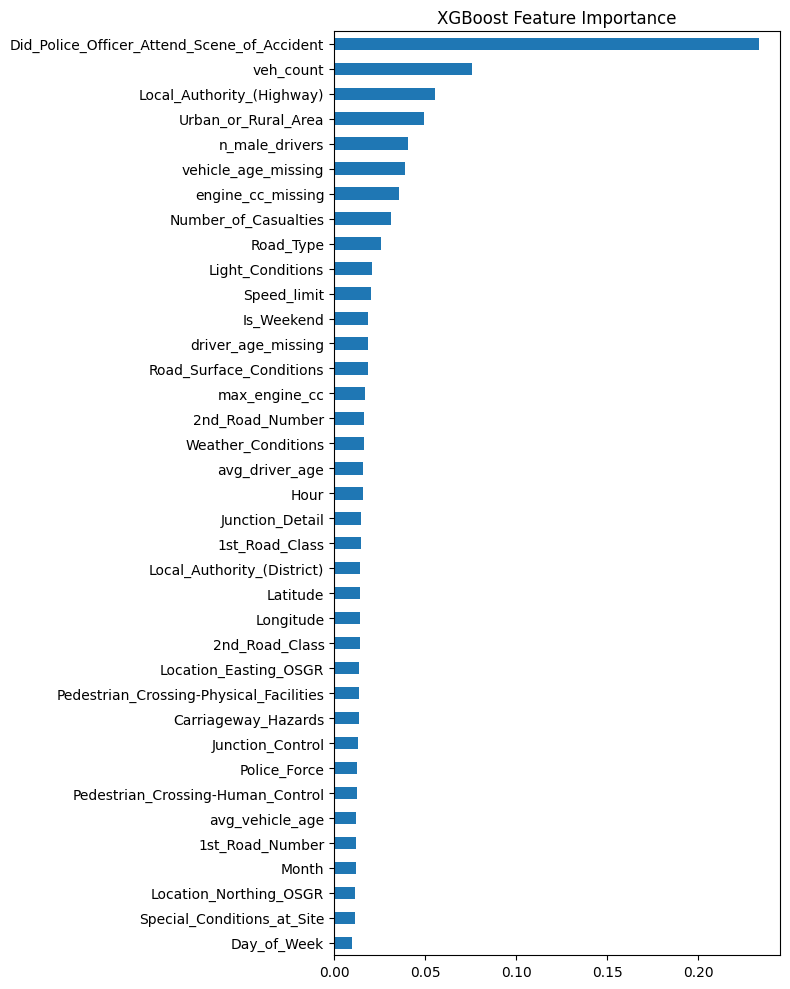

Did_Police_Officer_Attend_Scene_of_Accident    0.233290
veh_count                                      0.075682
Local_Authority_(Highway)                      0.055507
Urban_or_Rural_Area                            0.049643
n_male_drivers                                 0.040519
vehicle_age_missing                            0.038840
engine_cc_missing                              0.035708
Number_of_Casualties                           0.030994
Road_Type                                      0.025566
Light_Conditions                               0.021015
Speed_limit                                    0.020368
Is_Weekend                                     0.018871
driver_age_missing                             0.018669
Road_Surface_Conditions                        0.018468
max_engine_cc                                  0.017146
2nd_Road_Number                                0.016547
Weather_Conditions                             0.016393
avg_driver_age                                 0

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 10))
importances.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

In [27]:
cols_to_drop = [
    'Did_Police_Officer_Attend_Scene_of_Accident',
    'Junction_Control',
    '2nd_Road_Class',
]

X_train_v2 = X_train.drop(columns=cols_to_drop)
X_test_v2 = X_test.drop(columns=cols_to_drop)

print(f"Features before: {X_train.shape[1]}, after: {X_train_v2.shape[1]}")

Features before: 37, after: 34


`Did_Police_Officer_Attend_Scene_of_Accident` was by far the most "important" feature, which is a red flag for data leakage: police attendance is often decided based on an initial severity assessment, so it indirectly reveals the target. It was removed. `Junction_Control` and `2nd_Road_Class` had negligible importance and were also dropped to simplify the feature set. 

In [35]:
from xgboost import XGBClassifier

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.2f}")

xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb = evaluate_model('XGBoost', xgb, X_train_v2, y_train, X_test_v2, y_test)

scale_pos_weight = 3.94
===== XGBoost =====
Accuracy: 0.6347
Precision: 0.2897
Recall: 0.5536
F1: 0.3803
ROC-AUC: 0.6484
PR-AUC: 0.3279
Train_F1: 0.4477
CV_F1_mean: 0.3814
CV_F1_std: 0.0035
CV_ROC_AUC_mean: 0.6528
CV_PR_AUC_mean: 0.3313

Train F1 (0.4477) vs Test F1 (0.3803) -> gap = 0.0674

Confusion Matrix:
[[12811  6739]
 [ 2216  2748]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.66      0.74     19550
           1       0.29      0.55      0.38      4964

    accuracy                           0.63     24514
   macro avg       0.57      0.60      0.56     24514
weighted avg       0.74      0.63      0.67     24514



In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=50,
    scoring='average_precision',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
print("XGBoost best params:", xgb_search.best_params_)
print("XGBoost best CV PR-AUC:", xgb_search.best_score_)
best_xgb = xgb_search.best_estimator_

lgbm_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8, -1],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=50,
    scoring='average_precision',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)
print("LightGBM best params:", lgbm_search.best_params_)
print("LightGBM best CV PR-AUC:", lgbm_search.best_score_)
best_lgbm = lgbm_search.best_estimator_

best_xgb = evaluate_model('XGBoost (tuned)', xgb_search.best_estimator_, X_train, y_train, X_test, y_test, scale=False)
best_lgbm = evaluate_model('LightGBM (tuned)', lgbm_search.best_estimator_, X_train, y_train, X_test, y_test, scale=False)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
XGBoost best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.03}
XGBoost best CV PR-AUC: 0.3659127840232355
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM best params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': 8, 'learning_rate': 0.03}
LightGBM best CV PR-AUC: 0.36470901659647526
===== XGBoost (tuned) =====
Accuracy: 0.6433
Precision: 0.3088
Recall: 0.6152
F1: 0.4112
ROC-AUC: 0.6860
PR-AUC: 0.3538
Train_F1: 0.4659
CV_F1_mean: 0.4201
CV_F1_std: 0.0034
CV_ROC_AUC_mean: 0.6967
CV_PR_AUC_mean: 0.3659

Train F1 (0.4659) vs Test F1 (0.4112) -> gap = 0.0546

Confusion Matrix:
[[12715  6835]
 [ 1910  3054]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.65      0.74     19550
           1       0.31      0.62      0.41      4964

    accuracy                           0.64     24514
   macro avg       0.59      0.63      0.58     24514
weighted avg       0.76      0.64      0.68     24514

===== LightGBM (tuned) =====
Accuracy: 0.6412
Precision: 0.3067
Recall: 0.6124
F1: 0.4087
ROC-AUC: 0.6850
PR-AUC: 0.3528
Train_F1: 0.4

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

final_model = best_lgbm

y_proba = final_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold_f1 = thresholds[best_idx]

print(f"Default threshold (0.5) -> F1: {f1_score(y_test, (y_proba >= 0.5).astype(int)):.4f}")
print(f"Best F1 threshold ({best_threshold_f1:.3f}) -> "
      f"F1: {f1_scores[best_idx]:.4f}, Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

target_recall = 0.75
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    idx_for_recall = valid_idx[np.argmax(precisions[valid_idx])]
    threshold_for_recall = thresholds[idx_for_recall]
    print(f"\nThreshold for recall>={target_recall}: {threshold_for_recall:.3f}, "
          f"Precision: {precisions[idx_for_recall]:.4f}, Recall: {recalls[idx_for_recall]:.4f}")
    

Default threshold (0.5) -> F1: 0.4087
Best F1 threshold (0.485) -> F1: 0.4133, Precision: 0.3032, Recall: 0.6489

Threshold for recall>=0.75: 0.430, Precision: 0.2770, Recall: 0.7508


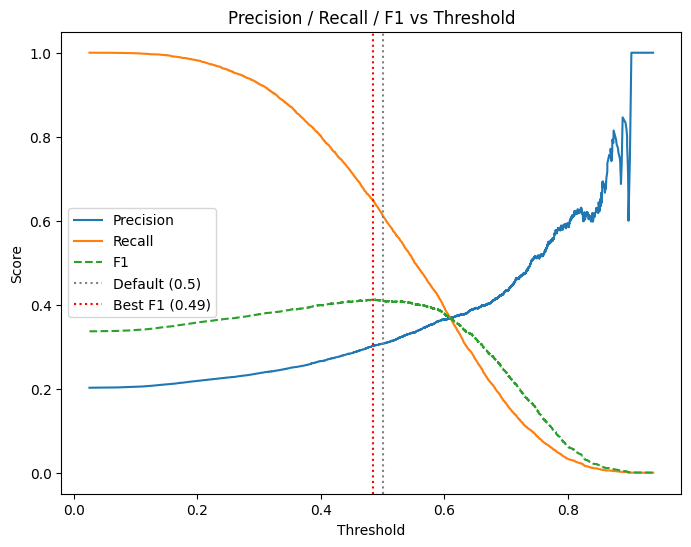

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1', linestyle='--')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
plt.axvline(x=best_threshold_f1, color='red', linestyle=':', label=f'Best F1 ({best_threshold_f1:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.show()

This plot shows the precision/recall/F1 trade-off across thresholds for the **LightGBM** model. The F1-optimal threshold (~0.49) is close to the default (0.5), but recall at that point is only ~60-65%.

In [ ]:
chosen_threshold = best_threshold_f1  
y_pred_final = (y_proba >= chosen_threshold).astype(int)
print(f"\n=== Final Evaluation @ threshold={chosen_threshold:.3f} ===")
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))


=== Final Evaluation @ threshold=0.485 ===
              precision    recall  f1-score   support

           0       0.87      0.62      0.73     19550
           1       0.30      0.65      0.41      4964

    accuracy                           0.63     24514
   macro avg       0.59      0.64      0.57     24514
weighted avg       0.76      0.63      0.66     24514

[[12148  7402]
 [ 1743  3221]]


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

final_model = best_xgb

y_proba = final_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold_f1 = thresholds[best_idx]

print(f"Default threshold (0.5) -> F1: {f1_score(y_test, (y_proba >= 0.5).astype(int)):.4f}")
print(f"Best F1 threshold ({best_threshold_f1:.3f}) -> "
      f"F1: {f1_scores[best_idx]:.4f}, Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")

target_recall = 0.75
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    idx_for_recall = valid_idx[np.argmax(precisions[valid_idx])]
    threshold_for_recall = thresholds[idx_for_recall]
    print(f"\nThreshold for recall>={target_recall}: {threshold_for_recall:.3f}, "
          f"Precision: {precisions[idx_for_recall]:.4f}, Recall: {recalls[idx_for_recall]:.4f}")



Default threshold (0.5) -> F1: 0.4112
Best F1 threshold (0.484) -> F1: 0.4123, Precision: 0.3016, Recall: 0.6511

Threshold for recall>=0.75: 0.432, Precision: 0.2768, Recall: 0.7500


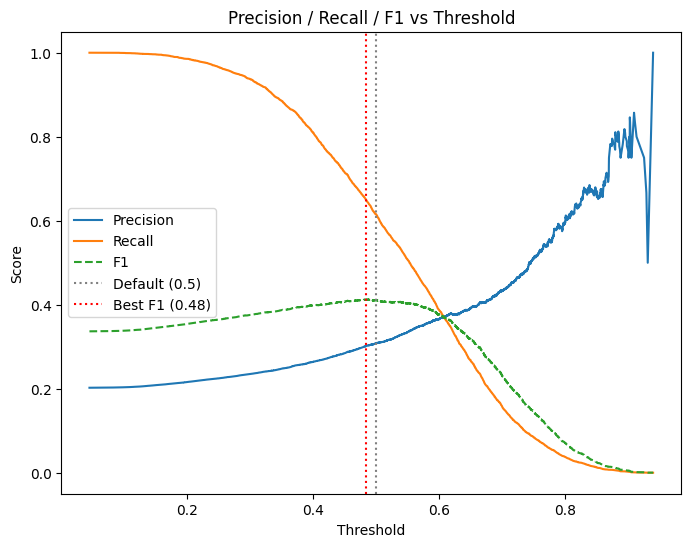

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1', linestyle='--')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
plt.axvline(x=best_threshold_f1, color='red', linestyle=':', label=f'Best F1 ({best_threshold_f1:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.show()

This plot shows the same trade-off for the **XGBoost** model (the one ultimately selected as the final model). The F1-optimal threshold (~0.48) gives a similar pattern, but a lower threshold was chosen afterward to prioritize recall in this road-safety context.

In [ ]:
chosen_threshold = best_threshold_f1
y_pred_final = (y_proba >= chosen_threshold).astype(int)
print(f"\n=== Final Evaluation @ threshold={chosen_threshold:.3f} ===")
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))


=== Final Evaluation @ threshold=0.484 ===
              precision    recall  f1-score   support

           0       0.87      0.62      0.72     19550
           1       0.30      0.65      0.41      4964

    accuracy                           0.62     24514
   macro avg       0.59      0.63      0.57     24514
weighted avg       0.76      0.62      0.66     24514

[[12067  7483]
 [ 1732  3232]]


In [34]:
import joblib
import json
import pandas as pd
from datetime import datetime
import os

In [36]:
save_dir = 'model_artifacts'
os.makedirs(save_dir, exist_ok=True)

In [70]:
final_model = best_xgb

model_path = os.path.join(save_dir, 'ksi_xgboost_final.pkl')
joblib.dump(final_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: model_artifacts/ksi_xgboost_final.pkl


In [71]:
final_threshold = 0.432

threshold_config = {
    'threshold': final_threshold,
    'rationale': 'Recall-prioritized (~0.75) over F1-optimal (0.484) — missing a real KSI accident '
                 'is costlier than a false alarm in a road-safety context.',
    'metrics_at_threshold': {
        'precision': 0.2768,
        'recall': 0.7500,
    },
    'metrics_at_f1_optimal_threshold_for_reference': {
        'threshold': 0.484,
        'precision': 0.3016,
        'recall': 0.6511,
        'f1': 0.4123,
    },
    'model_file': 'ksi_xgboost_final.pkl',
    'feature_columns': list(X_train.columns),
    'saved_at': datetime.now().isoformat(),
}

threshold_path = os.path.join(save_dir, 'threshold_config.json')
with open(threshold_path, 'w', encoding='utf-8') as f:
    json.dump(threshold_config, f, indent=2, ensure_ascii=False)
print(f"Threshold config saved to: {threshold_path}")

Threshold config saved to: model_artifacts/threshold_config.json


In [73]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

comparison_path = os.path.join(save_dir, 'model_comparison.csv')
comparison_df.to_csv(comparison_path)
print(f"Comparison table saved to: {comparison_path}")

print("\n=== Final Model Comparison ===")
comparison_df.round(4)

Comparison table saved to: model_artifacts/model_comparison.csv

=== Final Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train_F1,CV_F1_mean,CV_F1_std,CV_ROC_AUC_mean,CV_PR_AUC_mean
XGBoost (tuned),0.6433,0.3088,0.6152,0.4112,0.6860,0.3538,0.4659,0.4201,0.0034,0.6967,0.3659
LightGBM (tuned),0.6412,0.3067,0.6124,0.4087,0.6850,0.3528,0.4806,0.4173,0.0031,0.6961,0.3647
LightGBM,0.6427,0.3081,0.6140,0.4103,0.6839,0.3512,0.4687,0.4181,0.0029,0.6939,0.3624
Random Forest,0.7217,0.3441,0.4132,0.3755,0.6715,0.3355,0.6930,0.3695,0.0052,0.6798,0.3429
Logistic Regression,0.6038,0.2836,0.6267,0.3905,0.6591,0.3198,0.4034,0.4018,0.0031,0.6705,0.3341
XGBoost,0.6357,0.2902,0.5528,0.3806,0.6473,0.3281,0.4462,0.3825,0.0056,0.6526,0.3315
Decision Tree,0.6281,0.2919,0.5866,0.3898,0.6459,0.3021,0.4449,0.3913,0.0010,0.6474,0.2994


XGBoost (tuned) achieved the best ROC-AUC (0.686) and PR-AUC (0.354), making it the final model. Although Random Forest had the highest raw accuracy (0.72), its recall was much lower (0.41) and its train-test F1 gap was the largest (0.32), indicating overfitting and a bias toward the majority class — both undesirable in a road-safety context where missing severe accidents is costly.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler_km = StandardScaler()
X_train_scaled_km = scaler_km.fit_transform(X_train)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled_km)

import pandas as pd
print(pd.crosstab(clusters, y_train, rownames=['Cluster'], colnames=['is_KSI']))

is_KSI       0      1
Cluster              
0        45021  10155
1        33179   9698


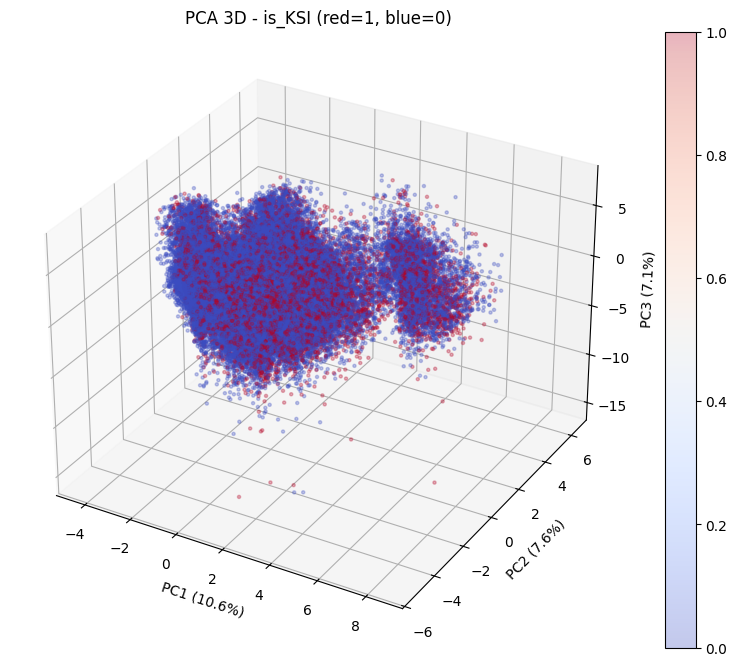

Total variance explained by 3 components: 25.3%


In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_scaled_km)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_train, cmap='coolwarm', alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
plt.title('PCA 3D - is_KSI (red=1, blue=0)')
plt.colorbar(scatter)
plt.show()

print(f"Total variance explained by 3 components: {pca.explained_variance_ratio_.sum():.1%}")

Projecting the features into 3 principal components (explaining only ~25% of total variance) shows no clear visual separation between KSI and Non-KSI accidents — the two classes are heavily overlapping. This confirms that the classification boundary is not simple or linear, which explains why tree-based models (XGBoost, LightGBM) outperformed linear models like Logistic Regression in the comparison table.

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report

X_train_normal = X_train_scaled_km[y_train == 0]

ocsvm = OneClassSVM(kernel='rbf', nu=0.2, gamma='scale')
ocsvm.fit(X_train_normal)

X_test_scaled_km = scaler_km.transform(X_test)
pred_ocsvm = ocsvm.predict(X_test_scaled_km)
pred_ocsvm_binary = (pred_ocsvm == -1).astype(int)

print(classification_report(y_test, pred_ocsvm_binary))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     19550
           1       0.22      0.21      0.21      4964

    accuracy                           0.68     24514
   macro avg       0.51      0.51      0.51     24514
weighted avg       0.68      0.68      0.68     24514



In [40]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(f"Before: {y_train.value_counts().to_dict()}")
print(f"After:  {pd.Series(y_train_under).value_counts().to_dict()}")

from xgboost import XGBClassifier

xgb_under = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
evaluate_model('XGBoost (undersampled)', xgb_under, X_train_under, y_train_under, X_test, y_test, scale=False)

Before: {0: 78200, 1: 19853}
After:  {0: 19853, 1: 19853}
===== XGBoost (undersampled) =====
Accuracy: 0.6278
Precision: 0.3022
Recall: 0.6398
F1: 0.4105
ROC-AUC: 0.6830
PR-AUC: 0.3478
Train_F1: 0.7039
CV_F1_mean: 0.6394
CV_F1_std: 0.0062
CV_ROC_AUC_mean: 0.6905
CV_PR_AUC_mean: 0.6716

Train F1 (0.7039) vs Test F1 (0.4105) -> gap = 0.2934

Confusion Matrix:
[[12215  7335]
 [ 1788  3176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.62      0.73     19550
           1       0.30      0.64      0.41      4964

    accuracy                           0.63     24514
   macro avg       0.59      0.63      0.57     24514
weighted avg       0.76      0.63      0.66     24514



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [41]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg = evaluate_model('Logistic Regression', log_reg_model, X_train_under, y_train_under, X_test, y_test, scale=True)

===== Logistic Regression =====
Accuracy: 0.6026
Precision: 0.2838
Recall: 0.6315
F1: 0.3916
ROC-AUC: 0.6586
PR-AUC: 0.3190
Train_F1: 0.6332
CV_F1_mean: 0.6331
CV_F1_std: 0.0059
CV_ROC_AUC_mean: 0.6719
CV_PR_AUC_mean: 0.6556

Train F1 (0.6332) vs Test F1 (0.3916) -> gap = 0.2416

Confusion Matrix:
[[11637  7913]
 [ 1829  3135]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.60      0.70     19550
           1       0.28      0.63      0.39      4964

    accuracy                           0.60     24514
   macro avg       0.57      0.61      0.55     24514
weighted avg       0.75      0.60      0.64     24514



In [42]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt = evaluate_model('Decision Tree', dt_model, X_train_under, y_train_under, X_test, y_test, scale=False)

===== Decision Tree =====
Accuracy: 0.6093
Precision: 0.2812
Recall: 0.5973
F1: 0.3824
ROC-AUC: 0.6339
PR-AUC: 0.2775
Train_F1: 0.6780
CV_F1_mean: 0.6035
CV_F1_std: 0.0080
CV_ROC_AUC_mean: 0.6403
CV_PR_AUC_mean: 0.6081

Train F1 (0.6780) vs Test F1 (0.3824) -> gap = 0.2956

Confusion Matrix:
[[11971  7579]
 [ 1999  2965]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.61      0.71     19550
           1       0.28      0.60      0.38      4964

    accuracy                           0.61     24514
   macro avg       0.57      0.60      0.55     24514
weighted avg       0.74      0.61      0.65     24514



In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', max_depth=15, random_state=42, n_jobs=-1)
rf = evaluate_model('Random Forest', rf_model, X_train_under, y_train_under, X_test, y_test, scale=False)

===== Random Forest =====
Accuracy: 0.6211
Precision: 0.2970
Recall: 0.6374
F1: 0.4052
ROC-AUC: 0.6785
PR-AUC: 0.3469
Train_F1: 0.8753
CV_F1_mean: 0.6419
CV_F1_std: 0.0043
CV_ROC_AUC_mean: 0.6908
CV_PR_AUC_mean: 0.6720

Train F1 (0.8753) vs Test F1 (0.4052) -> gap = 0.4701

Confusion Matrix:
[[12061  7489]
 [ 1800  3164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.62      0.72     19550
           1       0.30      0.64      0.41      4964

    accuracy                           0.62     24514
   macro avg       0.58      0.63      0.56     24514
weighted avg       0.75      0.62      0.66     24514



In [45]:
from lightgbm import LGBMClassifier
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
lgbm_model = LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_pos,random_state=42, n_jobs=-1, verbose=-1)
lgbm = evaluate_model('LightGBM', lgbm_model, X_train_under, y_train_under, X_test, y_test, scale=False)

===== LightGBM =====
Accuracy: 0.2949
Precision: 0.2201
Recall: 0.9762
F1: 0.3593
ROC-AUC: 0.6807
PR-AUC: 0.3472
Train_F1: 0.6963
CV_F1_mean: 0.6833
CV_F1_std: 0.0017
CV_ROC_AUC_mean: 0.6901
CV_PR_AUC_mean: 0.6729

Train F1 (0.6963) vs Test F1 (0.3593) -> gap = 0.3370

Confusion Matrix:
[[ 2383 17167]
 [  118  4846]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.12      0.22     19550
           1       0.22      0.98      0.36      4964

    accuracy                           0.29     24514
   macro avg       0.59      0.55      0.29     24514
weighted avg       0.80      0.29      0.25     24514



In [38]:
imputer_path = os.path.join(save_dir, 'iterative_imputer.pkl')
joblib.dump(imputer, imputer_path)

encoder_path = os.path.join(save_dir, 'target_encoder.pkl')
joblib.dump(te, encoder_path)

print("Saved:", model_path, imputer_path, encoder_path)

Saved: model_artifacts\ksi_xgboost_final.pkl model_artifacts\iterative_imputer.pkl model_artifacts\target_encoder.pkl
